In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import h5py
import os
from PIL import Image

In [19]:
'''Constants and constant stuff'''
hbar = 1.0
G    = 1.0
m    = 1.0

#grid stuff
dt = 0.005
L  = 6.0        #NOT real grid length, just Jacobi-space-length??
N  = 40         #grid points per axis

#creates our "axes"
q  = np.linspace(-L, L, N)
dq = q[1] - q[0]

print(f"Grid:    N = {N},  dq = {dq:.4f},  L = {L}")
print(f"Array:   N^4 = {N**4:,} points   (lab-coord N^6 would be {N**6:,})")
print(f"Memory:  {N**4 * 16 / 1024**2:.1f} MB per complex array")

# 4D meshgrid(eta_x, eta_y, lamda_x, lamda_y)
EX, EY, LX, LY = np.meshgrid(q,q,q,q, indexing='ij')

Grid:    N = 40,  dq = 0.3077,  L = 6.0
Array:   N^4 = 2,560,000 points   (lab-coord N^6 would be 4,096,000,000)
Memory:  39.1 MB per complex array


In [20]:
'''Wavefunction evolution stuff'''
# Conversion factors( i didnt wanna type the full thing out every time)
sqrt2=np.sqrt(2.0)
sqrt3_2 =np.sqrt(3.0 / 2.0)
inv_sq2 =1.0/sqrt2

#softening parameter
eps=dq/3.0

# r_{23}= |eta1|*sqrt(2)
r23_x= EX*sqrt2
r23_y= EY*sqrt2
r23 = np.sqrt(r23_x**2+r23_y**2+eps**2)

# r_{12}  =  |lam1*sqrt(3/2)  -  eta1/sqrt(2)|
r12_x = LX * sqrt3_2 - EX * inv_sq2
r12_y = LY * sqrt3_2 - EY * inv_sq2
r12   = np.sqrt(r12_x**2 + r12_y**2 + eps**2)

# r_{13}  =  |lam1*sqrt(3/2)  +  eta1/sqrt(2)|
r13_x = LX * sqrt3_2 + EX * inv_sq2
r13_y = LY * sqrt3_2 + EY * inv_sq2
r13   = np.sqrt(r13_x**2 + r13_y**2 + eps**2)

# Gravity (same form as before, just in Jacobi coords)
V = -G * m**2 * (1.0/r12 + 1.0/r23 + 1.0/r13)

print(f"Potential range:  min = {V.min():.3f},  max = {V.max():.3f}")

Potential range:  min = -11.959,  max = -0.250


In [21]:
'''Hamiltonian'''
def hamiltonian(psi):
    """
    H psi = T psi + V psi
    T = -(hbar^2/2m)(lap_eta + lap_lam)
    Finite-difference Laplacian over all 4 axes.
    """
    lap      = np.zeros_like(psi, dtype=complex)
    s        = (slice(1, -1),) * 4          # interior slice on all axes
    interior = psi[1:-1, 1:-1, 1:-1, 1:-1]

    for axis in range(4):                   # axes: eta_x, eta_y, lam_x, lam_y
        fwd = [slice(1, -1)] * 4
        bwd = [slice(1, -1)] * 4
        fwd[axis] = slice(2, None)          # psi[..., i+1, ...]
        bwd[axis] = slice(None, -2)         # psi[..., i-1, ...]
        lap[s] += (psi[tuple(fwd)] - 2*interior + psi[tuple(bwd)]) / dq**2

    T = -(hbar**2 / (2*m)) * lap
    U = V * psi
    return T + U


def dpsi_dt(psi):
    return (-1j / hbar) * hamiltonian(psi)


def psi_next(psi, dt):
    """4th-order Runge-Kutta time step."""
    k1 = dpsi_dt(psi)
    k2 = dpsi_dt(psi + 0.5*dt*k1)
    k3 = dpsi_dt(psi + 0.5*dt*k2)
    k4 = dpsi_dt(psi + dt*k3)
    return psi + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

In [22]:
'''Initial state'''
sigma= 3.0*dq
d = 5.0       #2-3 separation along x
eta_offsetx = 1
eta_offsety = -1
lambda_offsetx= 5
lambda_offsety= -5

#psi= np.exp(-(((EX - eta_offsetx)**2 + (EY - eta_offsety)**2) + ((LX - lambda_offsetx)**2 + (LY - lambda_offsety)**2)) /(4*sigma**2)) + 0j

#psi = (np.exp(-((EX-4)**2 + (EY-2.5)**2)/(4*(sigma+1)**2)) + np.exp(-((EX+3.5)**2 + (EY+3)**2)/(4*sigma**2)))*(np.exp(-((LX+2)**2 + (LY+1)**2)/(4*sigma**2)) + np.exp(-((LX-2.5)**2 + (LY+4.5)**2)/(4*(sigma+1)**2))) + 0j

'''psi = (
    1.0*np.exp(-((EX-4.7)**2 + (EY+1.8)**2)/(4*(sigma+0.4)**2))
    + 0.7*np.exp(-((EX+2.9)**2 + (EY-4.6)**2)/(4*(sigma+1.3)**2))
    + 1.3*np.exp(-((EX-0.8)**2 + (EY-0.2)**2)/(4*(sigma+0.8)**2))
) * (
    1.1*np.exp(-((LX+4.4)**2 + (LY+3.7)**2)/(4*(sigma+0.5)**2))
    + 0.6*np.exp(-((LX-1.1)**2 + (LY-4.8)**2)/(4*(sigma+1.6)**2))
    + 1.4*np.exp(-((LX+0.3)**2 + (LY-2.2)**2)/(4*(sigma+0.7)**2))
    + 0.8*np.exp(-((LX-4.9)**2 + (LY+0.9)**2)/(4*(sigma+1.1)**2))
) + 0j'''

psi = np.exp(-((EX-5)**2 + (EY-5)**2 + (LX - 0.3)**2 + (LY - 0)**2) / (4*sigma**2))

psi=psi / np.sqrt(np.sum(np.abs(psi)**2) * dq**4)



In [23]:
'''Running simulation'''
'''hint hint: ~2-3.5 minutes per 100 timesteps'''
t_steps=3000    # total number of time steps
plotting_period=20    # save every nth step

# Create a directory to save the output file
output_dir = 'data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_filepath = os.path.join(output_dir, 'psi_jacobi_2D.h5')

#writing to file
with h5py.File(output_filepath, 'w') as f:
    f.attrs['dt'] = dt
    f.attrs['dq'] = dq
    f.attrs['L']  = L
    f.attrs['N']  = N

    psi_run = psi.copy()
    for step in range(t_steps + 1):
        if step % plotting_period == 0:
            f.create_dataset(f'psi_{step:05d}', data=psi_run, compression='gzip')
            norm = np.sum(np.abs(psi_run)**2) * dq**4
            print(f"  step {step:4d} / {t_steps}    norm = {norm:.6f}    t = {step*dt:.3f}")
        psi_run  = psi_next(psi_run, dt)
        # Renormalisation
        psi_run /= np.sqrt(np.sum(np.abs(psi_run)**2) * dq**4)

print("Finished")

  step    0 / 3000    norm = 1.000000    t = 0.000
  step   20 / 3000    norm = 1.000000    t = 0.100
  step   40 / 3000    norm = 1.000000    t = 0.200
  step   60 / 3000    norm = 1.000000    t = 0.300
  step   80 / 3000    norm = 1.000000    t = 0.400
  step  100 / 3000    norm = 1.000000    t = 0.500
  step  120 / 3000    norm = 1.000000    t = 0.600
  step  140 / 3000    norm = 1.000000    t = 0.700
  step  160 / 3000    norm = 1.000000    t = 0.800
  step  180 / 3000    norm = 1.000000    t = 0.900
  step  200 / 3000    norm = 1.000000    t = 1.000
  step  220 / 3000    norm = 1.000000    t = 1.100
  step  240 / 3000    norm = 1.000000    t = 1.200
  step  260 / 3000    norm = 1.000000    t = 1.300
  step  280 / 3000    norm = 1.000000    t = 1.400
  step  300 / 3000    norm = 1.000000    t = 1.500
  step  320 / 3000    norm = 1.000000    t = 1.600
  step  340 / 3000    norm = 1.000000    t = 1.700
  step  360 / 3000    norm = 1.000000    t = 1.800
  step  380 / 3000    norm = 1.

In [26]:
'''Writing to file and making the fun plots'''
with h5py.File(output_filepath, 'r') as f:
    dt_s = f.attrs['dt']
    dq_s = f.attrs['dq']
    L_s  = f.attrs['L']
    keys = sorted(f.keys())
    n_plots = len(keys)
    ext = [-L_s, L_s, -L_s, L_s]


    fig, axes = plt.subplots(
        n_plots,
        3,
        figsize=(14, 3.5 * n_plots)
    )
    if n_plots == 1:
        axes = axes[np.newaxis, :]
    for row, key in enumerate(keys):
        psi_t = f[key][:]
        prob  = np.abs(psi_t)**2
        step = int(key.split('_')[1])
        time = step * dt_s

        # Marginals
        p_eta = np.sum(prob, axis=(2, 3)) * dq_s**2
        p_lam = np.sum(prob, axis=(0, 1)) * dq_s**2
        p_cross = np.sum(prob, axis=(1, 3)) * dq_s**2
        panels = [
            (p_eta,'η plane','η_x', 'η_y'),
            (p_lam,'λ plane','λ_x', 'λ_y'),
            (p_cross,'η_x vs λ_x','η_x', 'λ_x'),]
        for col, (density, title, xl, yl) in enumerate(panels):
            ax = axes[row, col]
            im = ax.imshow(
                density.T,
                origin='lower',
                extent=ext,
                cmap='inferno',
                aspect='equal')
            plt.colorbar(im, ax=ax)
            ax.set_xlabel(xl)
            ax.set_ylabel(yl)
            ax.set_title(f'{title}\nt = {time:.3f}')

plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, 'jacobi_2D_evolution.png'),
    dpi=120,
    bbox_inches='tight')
plt.show()

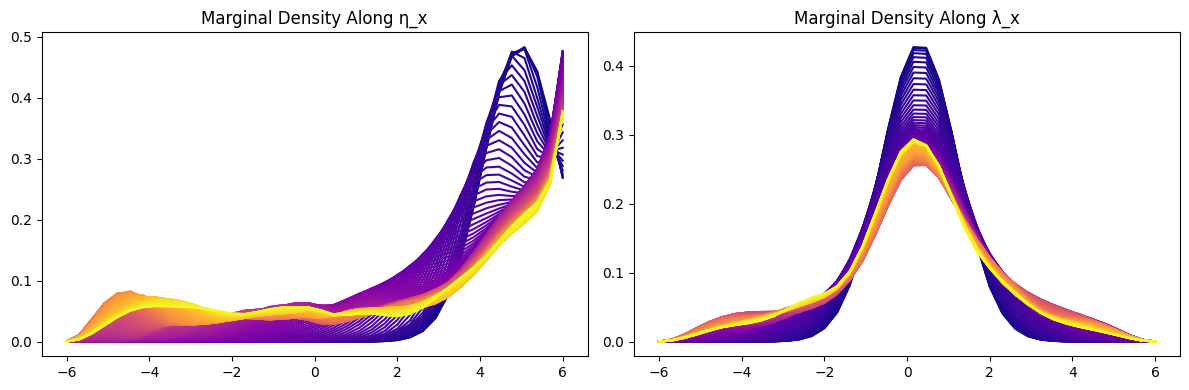

In [28]:
'''Marginal probabilities'''
with h5py.File(output_filepath, 'r') as f:
    #more plotting stuff yay
    dt_s = f.attrs['dt']
    dq_s = f.attrs['dq']
    keys = sorted(f.keys())
    n_plots = len(keys)
    colors = cm.plasma(np.linspace(0, 1, n_plots))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    #actual interesting part
    for i, key in enumerate(keys):
        psi_t = f[key][:]
        prob  = np.abs(psi_t)**2
        step = int(key.split('_')[1])
        lbl  = f't={step * dt_s:.2f}'
        p_eta_x = np.sum(prob, axis=(1, 2, 3)) * dq_s**3
        p_lam_x = np.sum(prob, axis=(0, 1, 3)) * dq_s**3
        axes[0].plot(q, p_eta_x, color=colors[i], label=lbl)
        axes[1].plot(q, p_lam_x, color=colors[i], label=lbl)

#and yet more plotting stuff
axes[0].set_title('Marginal Density Along η_x')
axes[1].set_title('Marginal Density Along λ_x')
plt.tight_layout()
plt.show()